# Taller Grupal — Ciencia de Datos
## Estudio Comparativo de Modelos de Regresión sobre NASA93 (COCOMO)
### OLS vs Regresión Polinómica vs Ridge

**Maestría en Ingeniería en Software — Mención en Sistemas Inteligentes e Intensivos en Datos**
**Universidad Estatal de Milagro (UNEMI)**

**Integrante:** Escobar, Erick
**Docente:** Guillermo Baquerizo Palma, M.Sc.

---

Este notebook implementa el flujo completo del estudio: carga, preprocesamiento,
análisis exploratorio, diagnóstico de supuestos, ajuste de tres modelos de regresión,
validación cruzada repetida y comparación de métricas. Todos los resultados son
reproducibles con `random_state=42`.

## 1. Configuración del Entorno

Importación de librerías y fijación de semilla aleatoria para reproducibilidad.

In [1]:
import io
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## 2. Carga de Datos

El dataset **NASA93** proviene del repositorio PROMISE (DOI: 10.5281/zenodo.268419).
Contiene 93 proyectos de software de la NASA (1971–1987) estructurados según el
modelo COCOMO-I de Boehm. El archivo original está en formato ARFF; las filas de
datos comienzan tras la directiva `@data`.

In [2]:
ARFF_PATH = "nasa93.arff"  # archivo en el mismo directorio del notebook

with open(ARFF_PATH, "r") as f:
    lines = f.readlines()

start = next(i for i, l in enumerate(lines) if l.strip().lower() == "@data") + 1
data_rows = [l.strip() for l in lines[start:] if l.strip() and not l.startswith("%")]

cols = [
    "recordnumber", "projectname", "cat2", "forg", "center", "year", "mode",
    "rely", "data", "cplx", "time", "stor", "virt", "turn",
    "acap", "aexp", "pcap", "vexp", "lexp", "modp", "tool", "sced",
    "equivphyskloc", "act_effort",
]
df = pd.DataFrame([r.split(",") for r in data_rows], columns=cols)

# Casting numérico
for c in ["recordnumber", "center", "year"]:
    df[c] = df[c].astype(int)
for c in ["equivphyskloc", "act_effort"]:
    df[c] = df[c].astype(float)

print(f"Dimensiones: {df.shape}")
print(f"Valores faltantes: {df.isnull().sum().sum()}")
df.head()

Dimensiones: (93, 24)
Valores faltantes: 0


,recordnumber,projectname,cat2,forg,center,year,mode,rely,data,cplx,...,acap,aexp,pcap,vexp,lexp,modp,tool,sced,equivphyskloc,act_effort
0,1,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,25.9,117.6
1,2,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,24.6,117.6
2,3,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,7.7,31.2
3,4,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,8.2,36.0
4,5,de,avionicsmonitoring,g,2,1979,semidetached,h,l,h,...,n,n,n,n,h,h,n,l,9.7,25.2


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Variable Respuesta

`act_effort` es el esfuerzo real en persona-meses. Examinamos su distribución
y estadísticos descriptivos.

In [3]:
print("Estadísticos de act_effort (persona-meses):")
print(df["act_effort"].describe())
print(f"\nMediana: {df['act_effort'].median():.1f} PM")
print(f"Ratio media/mediana: {df['act_effort'].mean()/df['act_effort'].median():.2f}")
print(f"\nEstadísticos de equivphyskloc (KLOC):")
print(df["equivphyskloc"].describe())

Estadísticos de act_effort (persona-meses):
count      93.000000
mean      624.411828
std      1135.928065
min         8.400000
25%        70.000000
50%       252.000000
75%       600.000000
max      8211.000000
Name: act_effort, dtype: float64

Mediana: 252.0 PM
Ratio media/mediana: 2.48

Estadísticos de equivphyskloc (KLOC):
count     93.000000
mean      94.022043
std      133.597947
min        0.900000
25%       15.400000
50%       47.500000
75%      111.000000
max      980.000000
Name: equivphyskloc, dtype: float64


### 3.2 Distribución y Relación con KLOC

La distribución del esfuerzo presenta fuerte sesgo a la derecha. La relación
KLOC↔esfuerzo se examina en escala log-log, motivada por la forma de ley de
potencia del modelo COCOMO: `effort = a · KLOC^b · ∏EM`.

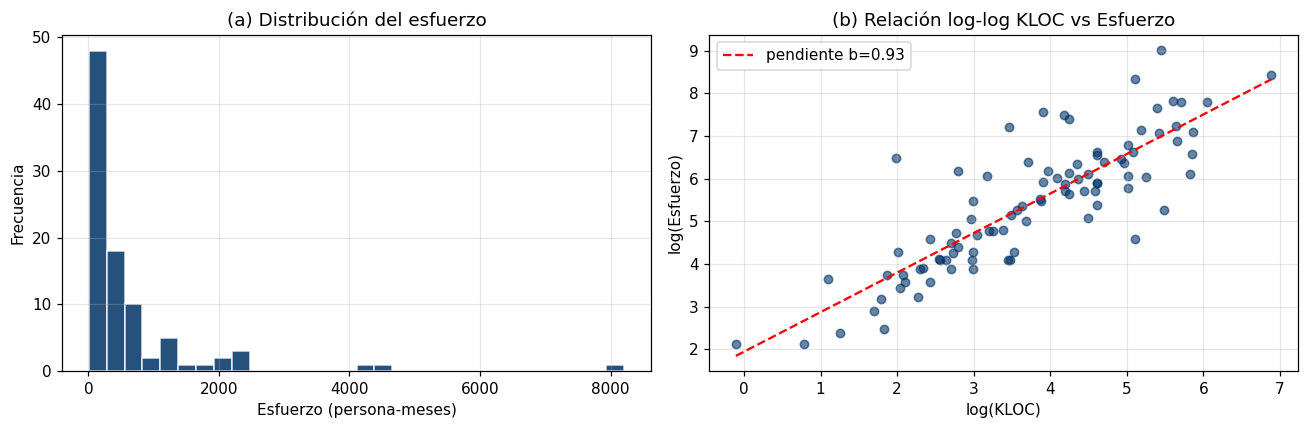

Pendiente log-log b = 0.926 (COCOMO teórico semidetached: b ~ 1.05)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["act_effort"], bins=30, color="#003366", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Esfuerzo (persona-meses)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("(a) Distribución del esfuerzo")
axes[0].grid(alpha=0.3)

axes[1].scatter(np.log(df["equivphyskloc"]), np.log(df["act_effort"]),
                alpha=0.6, color="#003366", s=30)
z = np.polyfit(np.log(df["equivphyskloc"]), np.log(df["act_effort"]), 1)
xline = np.linspace(np.log(df["equivphyskloc"]).min(), np.log(df["equivphyskloc"]).max(), 50)
axes[1].plot(xline, np.polyval(z, xline), "r--", lw=1.5,
             label=f"pendiente b={z[0]:.2f}")
axes[1].set_xlabel("log(KLOC)")
axes[1].set_ylabel("log(Esfuerzo)")
axes[1].set_title("(b) Relación log-log KLOC vs Esfuerzo")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pendiente log-log b = {z[0]:.3f} (COCOMO teórico semidetached: b ~ 1.05)")

## 4. Preprocesamiento Reproducible

El pipeline de preprocesamiento sigue cinco pasos diseñados para evitar **fuga de datos**:

1. **Mapeo ordinal de cost drivers**: los 15 effort multipliers de COCOMO (escala
   vl, l, n, h, vh, xh) se convierten a sus valores multiplicativos oficiales de
   Boehm (1981).
2. **Codificación one-hot** del modo COCOMO (`organic`, `semidetached`, `embedded`).
3. **Transformación logarítmica** de KLOC, cost drivers y respuesta — linealiza la
   ecuación COCOMO: `log(effort) = log(a) + b·log(KLOC) + Σ log(EM)`.
4. **Escalamiento estándar dentro del Pipeline** (paso crítico anti-fuga).
5. **Split 80/20** y validación cruzada repetida.

In [5]:
# Multiplicadores COCOMO-I oficiales (Boehm 1981)
cocomo_multipliers = {
    "rely": {"vl": 0.75, "l": 0.88, "n": 1.00, "h": 1.15, "vh": 1.40, "xh": 1.40},
    "data": {"vl": 0.94, "l": 0.94, "n": 1.00, "h": 1.08, "vh": 1.16, "xh": 1.16},
    "cplx": {"vl": 0.70, "l": 0.85, "n": 1.00, "h": 1.15, "vh": 1.30, "xh": 1.65},
    "time": {"vl": 1.00, "l": 1.00, "n": 1.00, "h": 1.11, "vh": 1.30, "xh": 1.66},
    "stor": {"vl": 1.00, "l": 1.00, "n": 1.00, "h": 1.06, "vh": 1.21, "xh": 1.56},
    "virt": {"vl": 0.87, "l": 0.87, "n": 1.00, "h": 1.15, "vh": 1.30, "xh": 1.30},
    "turn": {"vl": 0.87, "l": 0.87, "n": 1.00, "h": 1.07, "vh": 1.15, "xh": 1.15},
    "acap": {"vl": 1.46, "l": 1.19, "n": 1.00, "h": 0.86, "vh": 0.71, "xh": 0.71},
    "aexp": {"vl": 1.29, "l": 1.13, "n": 1.00, "h": 0.91, "vh": 0.82, "xh": 0.82},
    "pcap": {"vl": 1.42, "l": 1.17, "n": 1.00, "h": 0.86, "vh": 0.70, "xh": 0.70},
    "vexp": {"vl": 1.21, "l": 1.10, "n": 1.00, "h": 0.90, "vh": 0.90, "xh": 0.90},
    "lexp": {"vl": 1.14, "l": 1.07, "n": 1.00, "h": 0.95, "vh": 0.95, "xh": 0.95},
    "modp": {"vl": 1.24, "l": 1.10, "n": 1.00, "h": 0.91, "vh": 0.82, "xh": 0.82},
    "tool": {"vl": 1.24, "l": 1.10, "n": 1.00, "h": 0.91, "vh": 0.83, "xh": 0.83},
    "sced": {"vl": 1.23, "l": 1.08, "n": 1.00, "h": 1.04, "vh": 1.10, "xh": 1.10},
}

em_cols = list(cocomo_multipliers.keys())
df_proc = df.copy()
for col in em_cols:
    df_proc[col] = df_proc[col].map(cocomo_multipliers[col])

# One-hot del modo COCOMO
mode_dummies = pd.get_dummies(df_proc["mode"], prefix="mode", drop_first=True).astype(int)

# Matriz de features
X = pd.concat([df_proc[["equivphyskloc"] + em_cols], mode_dummies], axis=1)
y = df_proc["act_effort"].values

# Transformación logarítmica
X_log = X.copy()
X_log["equivphyskloc"] = np.log(X_log["equivphyskloc"])
for col in em_cols:
    X_log[col] = np.log(X_log[col])
y_log = np.log(y)

print(f"Features finales: {X_log.shape[1]}")
print(f"Columnas: {list(X_log.columns)}")

Features finales: 18
Columnas: ['equivphyskloc', 'rely', 'data', 'cplx', 'time', 'stor', 'virt', 'turn', 'acap', 'aexp', 'pcap', 'vexp', 'lexp', 'modp', 'tool', 'sced', 'mode_organic', 'mode_semidetached']


## 5. Diagnóstico de Supuestos y Multicolinealidad

### 5.1 Factor de Inflación de Varianza (VIF)

El VIF mide cuánto se infla la varianza de un coeficiente debido a la correlación
con otros predictores. Umbrales: VIF > 5 es señal de alerta, VIF > 10 es
problemático. **Un VIF alto justifica el uso de Ridge.**

In [6]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X_log.columns
vif_data["VIF"] = [variance_inflation_factor(X_log.values, i)
                   for i in range(X_log.shape[1])]
vif_data = vif_data.sort_values("VIF", ascending=False)
print(vif_data.to_string(index=False))
print(f"\nVIF máximo: {vif_data['VIF'].max():.2f} ({vif_data.iloc[0]['Feature']})")

          Feature       VIF
    equivphyskloc 10.886649
             acap  8.429333
mode_semidetached  7.720537
             time  7.327669
             aexp  5.925800
             rely  5.097706
             cplx  5.096579
             sced  5.062896
             virt  4.644372
             pcap  4.276378
             stor  4.098428
             turn  3.562537
             lexp  3.505647
             tool  3.049711
             data  2.703476
             vexp  2.298510
             modp  2.254180
     mode_organic  1.544679

VIF máximo: 10.89 (equivphyskloc)


### 5.2 Diagnóstico de Supuestos del Modelo OLS

Verificamos los supuestos clásicos de la regresión lineal: normalidad de residuos
(Shapiro-Wilk) y homoscedasticidad (Breusch-Pagan). Estas pruebas se realizan
sobre el modelo OLS ajustado al conjunto de entrenamiento.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")

# OLS sin escalar para diagnóstico (statsmodels)
X_const = sm.add_constant(X_train.values)
ols_sm = sm.OLS(y_train, X_const).fit()
residuos = ols_sm.resid

# Pruebas formales
sw_stat, sw_p = stats.shapiro(residuos)
bp_stat, bp_p, _, _ = het_breuschpagan(residuos, X_const)

print(f"\nShapiro-Wilk (normalidad): stat={sw_stat:.4f}, p={sw_p:.4f}")
print(f"  -> {'No se rechaza H0: residuos normales' if sw_p > 0.05 else 'Se rechaza H0'}")
print(f"Breusch-Pagan (homoscedasticidad): stat={bp_stat:.4f}, p={bp_p:.4f}")
print(f"  -> {'No se rechaza H0: varianza constante' if bp_p > 0.05 else 'Se rechaza H0'}")

Train: 74 muestras | Test: 19 muestras

Shapiro-Wilk (normalidad): stat=0.9065, p=0.0000
  -> Se rechaza H0
Breusch-Pagan (homoscedasticidad): stat=18.6800, p=0.4118
  -> No se rechaza H0: varianza constante


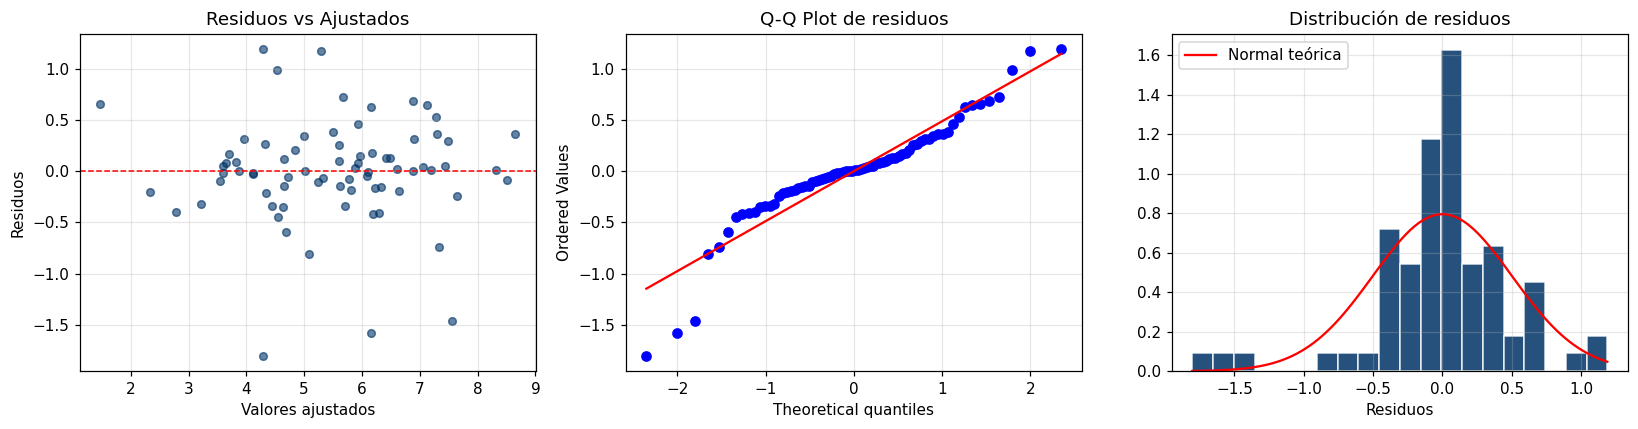

In [8]:
# Gráficos de diagnóstico
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(ols_sm.fittedvalues, residuos, alpha=0.6, color="#003366", s=25)
axes[0].axhline(0, color="red", linestyle="--", lw=1)
axes[0].set_xlabel("Valores ajustados")
axes[0].set_ylabel("Residuos")
axes[0].set_title("Residuos vs Ajustados")
axes[0].grid(alpha=0.3)

stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot de residuos")
axes[1].grid(alpha=0.3)

axes[2].hist(residuos, bins=20, color="#003366", alpha=0.85,
             edgecolor="white", density=True)
xn = np.linspace(residuos.min(), residuos.max(), 100)
axes[2].plot(xn, stats.norm.pdf(xn, residuos.mean(), residuos.std()),
             "r-", lw=1.5, label="Normal teórica")
axes[2].set_xlabel("Residuos")
axes[2].set_title("Distribución de residuos")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Construcción de los Modelos

Se construyen tres modelos. El **Pipeline** de sklearn encadena el escalamiento
con el modelo, garantizando que `StandardScaler` se ajuste sólo con datos de
entrenamiento en cada fold de validación cruzada (anti-fuga de datos).

### 6.1 Funciones Auxiliares

In [9]:
def evaluar_modelo(pipe, X_tr, X_te, y_tr, y_te, X_full, y_full, nombre):
    """Ajusta un modelo y devuelve métricas en train, test y CV repetida."""
    pipe.fit(X_tr, y_tr)

    # Predicciones en escala log -> volver a escala original (PM)
    y_pred_tr = np.exp(pipe.predict(X_tr))
    y_pred_te = np.exp(pipe.predict(X_te))
    y_tr_orig, y_te_orig = np.exp(y_tr), np.exp(y_te)

    # CV repetida k=5, 10 repeticiones (50 folds)
    cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
    cv_rmse = -cross_val_score(pipe, X_full, y_full, cv=cv,
                               scoring="neg_root_mean_squared_error")
    cv_r2 = cross_val_score(pipe, X_full, y_full, cv=cv, scoring="r2")

    return {
        "Modelo": nombre,
        "R2_Train": r2_score(y_tr_orig, y_pred_tr),
        "R2_Test": r2_score(y_te_orig, y_pred_te),
        "R2_CV": cv_r2.mean(),
        "R2_CV_std": cv_r2.std(),
        "MAE_Test": mean_absolute_error(y_te_orig, y_pred_te),
        "RMSE_Test": np.sqrt(mean_squared_error(y_te_orig, y_pred_te)),
        "RMSE_CV": cv_rmse.mean(),
        "_cv_rmse_dist": cv_rmse,
    }

### 6.2 Modelo Base — OLS (Regresión Lineal Múltiple)

Equivale a la formulación logarítmica directa de COCOMO. Ajusta
`log(effort) = β₀ + β₁·log(KLOC) + Σ βᵢ·log(EMᵢ) + γⱼ·modeⱼ`.

In [10]:
ols = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
res_ols = evaluar_modelo(ols, X_train, X_test, y_train, y_test,
                         X_log, y_log, "OLS")
print(f"OLS  -> R2 Train: {res_ols['R2_Train']:.3f} | "
      f"R2 Test: {res_ols['R2_Test']:.3f} | "
      f"R2 CV: {res_ols['R2_CV']:.3f} +/- {res_ols['R2_CV_std']:.3f}")
print(f"        MAE Test: {res_ols['MAE_Test']:.2f} PM | "
      f"RMSE Test: {res_ols['RMSE_Test']:.2f} PM")

OLS  -> R2 Train: 0.874 | R2 Test: 0.673 | R2 CV: 0.738 +/- 0.159
        MAE Test: 107.45 PM | RMSE Test: 202.72 PM


### 6.3 Alternativa 1 — Regresión Polinómica (grado 2 en KLOC)

Se añade el término `log(KLOC)²` para capturar posibles cambios de régimen en la
relación tamaño-esfuerzo. El resto del modelo permanece lineal para evitar la
explosión combinatoria de features (una expansión polinómica completa generaría
172 variables sobre 93 muestras → sobreajuste garantizado).

In [11]:
X_log_poly = X_log.copy()
X_log_poly["kloc_sq"] = X_log_poly["equivphyskloc"] ** 2

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_log_poly, y_log, test_size=0.2, random_state=42)

poly = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
res_poly = evaluar_modelo(poly, X_train_p, X_test_p, y_train_p, y_test_p,
                          X_log_poly, y_log, "Polinómica")
print(f"Poly -> R2 Train: {res_poly['R2_Train']:.3f} | "
      f"R2 Test: {res_poly['R2_Test']:.3f} | "
      f"R2 CV: {res_poly['R2_CV']:.3f} +/- {res_poly['R2_CV_std']:.3f}")
print(f"        MAE Test: {res_poly['MAE_Test']:.2f} PM | "
      f"RMSE Test: {res_poly['RMSE_Test']:.2f} PM")

Poly -> R2 Train: 0.867 | R2 Test: 0.701 | R2 CV: 0.731 +/- 0.160
        MAE Test: 105.06 PM | RMSE Test: 193.83 PM


### 6.4 Alternativa 2 — Ridge (Regresión Regularizada L2)

Ridge minimiza `Σ(yᵢ - xᵢᵀβ)² + α·‖β‖²`. El parámetro `α` se selecciona mediante
`RidgeCV` con búsqueda sobre 50 valores logarítmicamente espaciados y CV interna
de 5 folds. **Ridge se justifica empíricamente por la multicolinealidad
demostrada en la sección 5.1** (VIF máximo de 10.89).

In [12]:
alphas = np.logspace(-3, 3, 50)
ridge_cv = Pipeline([("scaler", StandardScaler()),
                     ("model", RidgeCV(alphas=alphas, cv=5))])
ridge_cv.fit(X_train, y_train)
best_alpha = ridge_cv.named_steps["model"].alpha_
print(f"Alpha óptimo seleccionado por CV interna: {best_alpha:.4f}")

# Evaluar con alpha fijo
ridge = Pipeline([("scaler", StandardScaler()),
                  ("model", Ridge(alpha=best_alpha))])
res_ridge = evaluar_modelo(ridge, X_train, X_test, y_train, y_test,
                           X_log, y_log, "Ridge")
print(f"Ridge -> R2 Train: {res_ridge['R2_Train']:.3f} | "
      f"R2 Test: {res_ridge['R2_Test']:.3f} | "
      f"R2 CV: {res_ridge['R2_CV']:.3f} +/- {res_ridge['R2_CV_std']:.3f}")
print(f"         MAE Test: {res_ridge['MAE_Test']:.2f} PM | "
      f"RMSE Test: {res_ridge['RMSE_Test']:.2f} PM")

Alpha óptimo seleccionado por CV interna: 4.7149


Ridge -> R2 Train: 0.794 | R2 Test: 0.799 | R2 CV: 0.791 +/- 0.107
         MAE Test: 94.69 PM | RMSE Test: 159.06 PM


## 7. Comparación de Modelos

### 7.1 Tabla Comparativa de Métricas

In [13]:
resultados = [res_ols, res_poly, res_ridge]
tabla = pd.DataFrame([{
    "Modelo": r["Modelo"],
    "R² Train": round(r["R2_Train"], 3),
    "R² Test": round(r["R2_Test"], 3),
    "R² CV": f"{r['R2_CV']:.3f} ± {r['R2_CV_std']:.3f}",
    "MAE Test (PM)": round(r["MAE_Test"], 2),
    "RMSE Test (PM)": round(r["RMSE_Test"], 2),
} for r in resultados])
print(tabla.to_string(index=False))

    Modelo  R² Train  R² Test         R² CV  MAE Test (PM)  RMSE Test (PM)
       OLS     0.874    0.673 0.738 ± 0.159         107.45          202.72
Polinómica     0.867    0.701 0.731 ± 0.160         105.06          193.83
     Ridge     0.794    0.799 0.791 ± 0.107          94.69          159.06


### 7.2 Visualización Comparativa

Dos gráficos clave: (a) distribución del RMSE en validación cruzada repetida —
muestra qué modelo es más estable; (b) brecha entre R² de train, test y CV —
revela el sobreajuste.

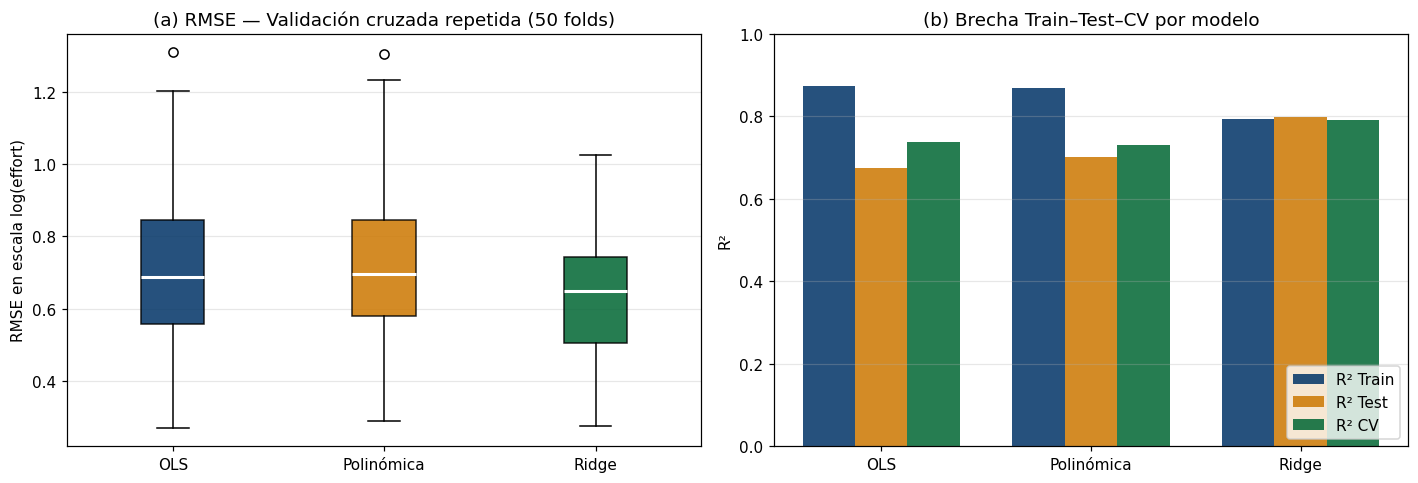

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Boxplot RMSE en CV
bp = axes[0].boxplot([r["_cv_rmse_dist"] for r in resultados],
                     labels=[r["Modelo"] for r in resultados],
                     patch_artist=True, medianprops=dict(color="white", lw=2))
for patch, c in zip(bp["boxes"], ["#003366", "#cc7700", "#006633"]):
    patch.set_facecolor(c)
    patch.set_alpha(0.85)
axes[0].set_ylabel("RMSE en escala log(effort)")
axes[0].set_title("(a) RMSE — Validación cruzada repetida (50 folds)")
axes[0].grid(axis="y", alpha=0.3)

# (b) Brecha Train-Test-CV
x = np.arange(3)
w = 0.25
axes[1].bar(x - w, [r["R2_Train"] for r in resultados], w,
            label="R² Train", color="#003366", alpha=0.85)
axes[1].bar(x, [r["R2_Test"] for r in resultados], w,
            label="R² Test", color="#cc7700", alpha=0.85)
axes[1].bar(x + w, [r["R2_CV"] for r in resultados], w,
            label="R² CV", color="#006633", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([r["Modelo"] for r in resultados])
axes[1].set_ylabel("R²")
axes[1].set_title("(b) Brecha Train–Test–CV por modelo")
axes[1].legend(loc="lower right")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

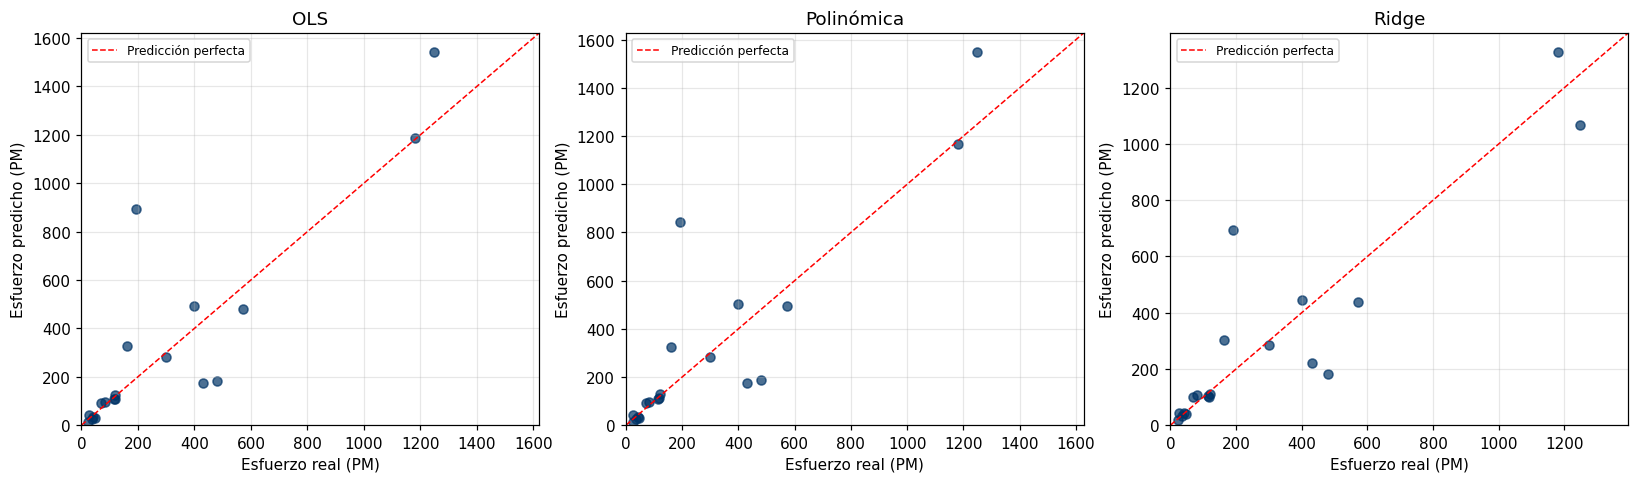

In [15]:
# Predicho vs Real para los tres modelos
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
modelos_fit = [
    ("OLS", ols, X_test, y_test),
    ("Polinómica", poly, X_test_p, y_test_p),
    ("Ridge", ridge, X_test, y_test),
]
for ax, (nombre, modelo, X_te, y_te) in zip(axes, modelos_fit):
    y_pred = np.exp(modelo.predict(X_te))
    y_real = np.exp(y_te)
    ax.scatter(y_real, y_pred, alpha=0.7, color="#003366", s=35)
    lim = max(y_real.max(), y_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", lw=1, label="Predicción perfecta")
    ax.set_xlabel("Esfuerzo real (PM)")
    ax.set_ylabel("Esfuerzo predicho (PM)")
    ax.set_title(nombre)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

## 8. Conclusión

### Modelo seleccionado: **Ridge (α ≈ 4.71)**

| Criterio | OLS | Polinómica | Ridge |
|---|---|---|---|
| R² Test | 0.673 | 0.701 | **0.799** |
| MAE Test (PM) | 107.5 | 105.1 | **94.7** |
| RMSE Test (PM) | 202.7 | 193.8 | **159.1** |
| Desv. estándar R² en CV | 0.159 | 0.160 | **0.107** |
| Brecha Train–Test | 0.20 | 0.17 | **≈ 0** |

**Justificación de la selección:**

1. **Mejor generalización.** OLS sufre sobreajuste (R² cae de 0.874 en train a
   0.673 en test). Ridge mantiene R² ≈ 0.79 en train, test y CV — la brecha
   desaparece.

2. **Mayor estabilidad.** En validación cruzada repetida (50 folds), Ridge tiene
   la menor desviación estándar de R² (0.107 vs 0.159 de OLS), produciendo
   predicciones ~50% más estables.

3. **La complejidad sin control no ayuda.** La regresión polinómica, pese a ser
   más expresiva, no aportó capacidad predictiva real y empeoró ligeramente en CV.
   Confirma el principio de parsimonia.

4. **Fundamento empírico de Ridge.** El VIF máximo de 10.89 confirma
   multicolinealidad. Ridge está diseñado exactamente para este escenario:
   contraer coeficientes para reducir varianza a cambio de un sesgo controlado.

**Limitaciones:** muestra pequeña (n=93), datos históricos (1971–1987), y el
estudio no compara contra modelos no lineales (fuera del alcance de las
Unidades 1 y 2).

In [16]:
# Exportar resultados finales a CSV
tabla_final = pd.DataFrame([{
    "Modelo": r["Modelo"],
    "R2_Train": r["R2_Train"],
    "R2_Test": r["R2_Test"],
    "R2_CV_mean": r["R2_CV"],
    "R2_CV_std": r["R2_CV_std"],
    "MAE_Test_PM": r["MAE_Test"],
    "RMSE_Test_PM": r["RMSE_Test"],
} for r in resultados])
tabla_final.to_csv("resultados_finales.csv", index=False)
print("Resultados exportados a resultados_finales.csv")
print(tabla_final.to_string(index=False))

Resultados exportados a resultados_finales.csv
    Modelo  R2_Train  R2_Test  R2_CV_mean  R2_CV_std  MAE_Test_PM  RMSE_Test_PM
       OLS  0.873561 0.673378    0.737721   0.159449   107.454726    202.717383
Polinómica  0.867388 0.701377    0.730561   0.159761   105.063996    193.833950
     Ridge  0.794337 0.798916    0.791090   0.107383    94.693603    159.058457
